In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
pd.set_option("future.no_silent_downcasting", True)
 
from laparoscopy_helpers.data_cleaning import to_snake_case, clean_surgical_df
from poor_patient_helpers.data_cleaning import load_all_endo, load_all_mercy, load_all_safe, build_final

In [2]:
TB = pd.read_excel(
    "../Nkhoma_data/theatre_book_data/combined_clean.xlsx",
    engine="openpyxl"
)

In [3]:
base_path = "../Nkhoma_data/poor_patients_funds_data"

endo  = load_all_endo(f"{base_path}/Endoscopy Ledger")
mercy = load_all_mercy(f"{base_path}/Mercy Fund")
safe  = load_all_safe(f"{base_path}/SAFE")

✓ endo  22 May               → 14 rows
✓ endo  22 June              → 7 rows
✓ endo  22 Aug               → 14 rows
✓ endo  22 Sept              → 6 rows
✓ endo  22 Oct               → 5 rows
✓ endo  22 Nov               → 7 rows
✓ endo  22 Dec               → 6 rows
✓ endo  23 JAN               → 9 rows
✓ endo  23 FEB               → 11 rows
✓ endo  23 MAR               → 9 rows
✓ endo  23 APR               → 16 rows
✓ endo  23 MAY               → 6 rows
✓ endo  23 SEPT              → 21 rows
✓ endo  23 OCT               → 4 rows
✓ endo  23 NOV               → 14 rows
✓ endo  23 DEC               → 9 rows
✓ endo  2024 FULL LIST       → 124 rows
✓ endo  January              → 15 rows
✓ endo  February             → 15 rows
✓ endo  March                → 20 rows
✓ endo  April                → 20 rows
✓ endo  May                  → 20 rows
✓ endo  June                 → 25 rows
✓ endo  July                 → 20 rows
✓ endo  August               → 28 rows
✓ endo  September            → 27 

In [4]:
final = build_final(TB, mercy, safe, endo, verbose=True)


Final shape: (2655, 42)

Match status:
match_status  matched  unmatched
fund                            
endo              431         78
mercy            1273        268
safe              506         99

Matched dept distribution:
department  Gen_Surg  Ortho
fund                       
endo             431      0
mercy           1203     70
safe             359    147

Cross-fund double-billing flags: 19


/home/mat2m10/code/mat2m10/nkhoma/notebooks/poor_patient_helpers/data_cleaning.py:688: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  links = pd.concat([mercy_links, safe_links, endo_links], ignore_index=True)


In [5]:
matched = final[final["match_status"] == "matched"].copy()
unmatched = final[final["match_status"] == "unmatched"].copy()

In [6]:
matched

,fund,match_status,match_type,fuzzy_score,unmatched_reason,cross_fund_flag,fund_name,patient_number,age,gender,...,procedure_free_text,tb_surgery_type,indication_for_surgery,urgency,surgery_severity,asascore,days_since_last_mercy,possible_duplicate_mercy,days_since_last_safe,possible_duplicate_safe
0,mercy,matched,exact,1.000,None,False,MOSES MANGUISA,66,NaN,Male,...,open prostatectomy / BPH / medium sized smooth...,Urology,Non-Communicable Disease,NaN,NaN,ASA 2,NaN,False,NaN,NaN
1,mercy,matched,fuzzy,0.903,None,False,KACHIGAMBA MWALE,276,NaN,Male,...,Rt hemithyroidectomy / enlarged Rt thyroid wit...,"Ent, Visceral Surg, Cardiothoracic, Vascular",Non-Communicable Disease,NaN,NaN,ASA 2,NaN,False,NaN,NaN
2,mercy,matched,exact,1.000,None,False,EFRINA CHIKONDI,362,NaN,Female,...,Laparotomy converted to open / acute abdomen /...,Any Other Surgery,Infection,NaN,NaN,ASA 1,NaN,False,NaN,NaN
3,mercy,matched,exact,1.000,None,False,PAMELA MWELWA,706,NaN,Female,...,Ex-Lap w/ esophageal perforation repair / hiat...,"Ent, Visceral Surg, Cardiothoracic, Vascular",Non-Communicable Disease,NaN,NaN,ASA 1,NaN,False,NaN,NaN
4,mercy,matched,fuzzy,0.917,None,False,ERIC MALINGA,922,NaN,Male,...,Open prostatectomy,Urology,Non-Communicable Disease,Elective,NaN,ASA 1,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2649,endo,matched,fuzzy,0.938,None,False,FRANK MTAMBALIKA,20393,NaN,Male,...,EUA,Any Other Surgery,Non-Communicable Disease,Elective,Minor,ASA 1,NaN,NaN,NaN,NaN
2651,endo,matched,exact,1.000,None,False,CATHERINE SAMUEL,13286,NaN,Female,...,EGD,Any Other Surgery,Non-Communicable Disease,Emergency,Minor,ASA 2,NaN,NaN,NaN,NaN
2652,endo,matched,fuzzy,0.857,None,False,IBULA MALUWILE,33273,NaN,Male,...,EGD + Biopsy,Any Other Surgery,Non-Communicable Disease,Elective,Minor,ASA 2,NaN,NaN,NaN,NaN
2653,endo,matched,exact,1.000,None,False,FREDSON KAMETA,32559,NaN,Male,...,EGD + Banding,Any Other Surgery,Non-Communicable Disease,Emergency,Minor,ASA 2,NaN,NaN,NaN,NaN


In [7]:
not_in_TB = unmatched[unmatched['unmatched_reason'] != "outside_TB_range"]

In [8]:
not_in_TB

,fund,match_status,match_type,fuzzy_score,unmatched_reason,cross_fund_flag,fund_name,patient_number,age,gender,...,procedure_free_text,tb_surgery_type,indication_for_surgery,urgency,surgery_severity,asascore,days_since_last_mercy,possible_duplicate_mercy,days_since_last_safe,possible_duplicate_safe
7,mercy,unmatched,unmatched,NaN,not_in_TB,False,KARO THOM,1023,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
11,mercy,unmatched,unmatched,NaN,not_in_TB,False,HAISAN KARONGA,1522,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,82.0,False,NaN,NaN
23,mercy,unmatched,unmatched,NaN,not_in_TB,False,ELEMU CHIDZAMA,2541,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
25,mercy,unmatched,unmatched,NaN,not_in_TB,False,JUDITH CHISEMBE,2812,NaN,Female,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
35,mercy,unmatched,unmatched,NaN,not_in_TB,False,DISHAN BAULENI,3874,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2638,endo,unmatched,unmatched,NaN,not_in_TB,False,ELIDIO ADRAIA GOBUAZA,30792,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
2639,endo,unmatched,unmatched,NaN,not_in_TB,False,ELIDIO ADRAIA GOBUAZA,30792,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
2643,endo,unmatched,unmatched,NaN,not_in_TB,False,HILDA DEVIOUS,32079,NaN,female,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
2647,endo,unmatched,unmatched,NaN,not_in_TB,False,OWEN RICHARD,33500,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN


In [9]:
# ── 1. Department distribution ────────────────────────────────────────────────
print("=== Q1: Department distribution (matched only) ===")
print(matched.groupby(["fund", "department"]).size().unstack(fill_value=0))
print("Note: endo dept comes from TB match — all endo procedures are Gen_Surg (GI)")

# ── 2. Cross-fund overlap — deduplicated before merge ────────────────────────
print("\n=== Q2: Cross-fund overlap ===")
mercy_ids = set(final[final["fund"]=="mercy"]["patient_number"].dropna().astype(str))
safe_ids  = set(final[final["fund"]=="safe"] ["patient_number"].dropna().astype(str))
endo_ids  = set(final[final["fund"]=="endo"] ["patient_number"].dropna().astype(str))
ms, me, se = mercy_ids & safe_ids, mercy_ids & endo_ids, safe_ids & endo_ids
print(f"Mercy ∩ Safe:  {len(ms)}  ← should be ~0")
print(f"Mercy ∩ Endo:  {len(me)}  ← expected (surgery + endoscopy same patient)")
print(f"Safe  ∩ Endo:  {len(se)}  ← expected (surgery + endoscopy same patient)")

if ms:
    # Deduplicate to ONE earliest admission per patient per fund before merging
    # — prevents cartesian explosion when a patient has multiple rows in both funds
    mercy_dedup = (final[final["fund"]=="mercy"]
                   .sort_values("fund_admission_date")
                   .drop_duplicates(subset=["patient_number"], keep="first")
                   [["patient_number","fund_admission_date","fund_name"]])
    safe_dedup  = (final[final["fund"]=="safe"]
                   .sort_values("fund_admission_date")
                   .drop_duplicates(subset=["patient_number"], keep="first")
                   [["patient_number","fund_admission_date","fund_name"]])
    ms_df = mercy_dedup.merge(safe_dedup, on="patient_number", suffixes=("_mercy","_safe"))
    ms_df["days_apart"] = (
        pd.to_datetime(ms_df["fund_admission_date_mercy"]) -
        pd.to_datetime(ms_df["fund_admission_date_safe"])
    ).dt.days.abs()
    suspicious = ms_df[ms_df["days_apart"] <= 14]
    print(f"\n  Suspicious Mercy∩Safe (≤14 days, deduplicated): {len(suspicious)} unique patients")
    print(suspicious[["patient_number","fund_name_mercy","fund_name_safe","days_apart"]]
          .to_string(index=False))
    legitimate = ms_df[ms_df["days_apart"] > 14]
    print(f"  Legitimate (different admissions >14 days apart): {len(legitimate)}")

# ── 3. Procedures per fund entry ─────────────────────────────────────────────
print("\n=== Q3: Procedures per fund entry ===")
multi = (matched
    .groupby(["fund","fund_name","fund_admission_date"])["theatre_index"]
    .count()
    .reset_index(name="n_procedures"))
print(multi.groupby("fund")["n_procedures"].value_counts().sort_index())
print("\nSample multi-procedure cases:")
print(multi[multi["n_procedures"] > 1]
      .sort_values(["fund","n_procedures"], ascending=[True,False])
      .head(10).to_string(index=False))

# ── 4. Coverage summary ───────────────────────────────────────────────────────
print("\n=== Q4: Theatre book + Endo coverage ===")
tb_total   = len(TB[TB["department"].isin(["Gen_Surg","Ortho"])])
tb_covered = matched[matched["fund"].isin(["mercy","safe"])]["theatre_index"].nunique()
print(f"TB Gen_Surg + Ortho total:             {tb_total}")
print(f"Covered by Mercy or SAFE:              {tb_covered}  ({tb_covered/tb_total:.1%})")
print("\nBy fund:")
print(matched[matched["fund"].isin(["mercy","safe"])].groupby("fund")["theatre_index"].nunique())

endo_total   = len(final[final["fund"]=="endo"])
endo_matched_n = matched[matched["fund"]=="endo"]["theatre_index"].nunique()
endo_unmatched = unmatched[unmatched["fund"]=="endo"]
print(f"\nEndo fund entries total:               {endo_total}")
print(f"Endo matched:                          {endo_matched_n}  ({endo_matched_n/endo_total:.1%})")
print(f"Endo unmatched — outside TB range:     {len(endo_unmatched[endo_unmatched['unmatched_reason']=='outside_TB_range'])}  (likely 2022-2023 nameless sheets)")
print(f"Endo unmatched — within TB range:      {len(endo_unmatched[endo_unmatched['unmatched_reason']=='not_in_TB'])}  (name mismatch or missing TB entry)")

# ── 5. Procedure breakdown ────────────────────────────────────────────────────
print("\n=== Q5: What procedures were covered? ===")
proc_table = (matched
    .groupby(["fund","tb_diagnosis"]).size()
    .reset_index(name="n")
    .pivot_table(index="tb_diagnosis", columns="fund",
                 values="n", fill_value=0)
    .sort_values("mercy", ascending=False))
print(proc_table.head(20).to_string())

# ── 6. Unmatched breakdown ────────────────────────────────────────────────────
print("\n=== Q6: Unmatched fund entries ===")
print(unmatched.groupby(["fund","unmatched_reason"]).size().unstack(fill_value=0))
print(f"\nTotal unmatched within TB range: {len(unmatched[unmatched['unmatched_reason']=='not_in_TB'])}")
print(unmatched[unmatched["unmatched_reason"]=="not_in_TB"].groupby("fund").size())

# ── 7. Financial summary — SAFE excluded from MK totals ──────────────────────
print("\n=== Q7: Financial summary ===")
fin = (matched
    .drop_duplicates(subset=["fund","fund_name","fund_admission_date"])
    .groupby("fund")
    .agg(
        n_cases        =("fund_name",        "count"),
        total_billed   =("total_bill_mk",    "sum"),
        total_copay    =("copay_mk",         "sum"),
        total_covered  =("fund_covered_mk",  "sum"),
    ))
fin["avg_covered_per_case"] = (fin["total_covered"] / fin["n_cases"]).round(0)
print(fin.to_string())

# MK totals excluding SAFE (whose fund_covered_mk is meaningless)
mk_funds = fin.loc[["endo","mercy"]]
print(f"\nCombined Endo + Mercy (reliable MK figures):")
print(f"  Total billed:   {mk_funds['total_billed'].sum():>15,.0f} MK")
print(f"  Total copay:    {mk_funds['total_copay'].sum():>15,.0f} MK")
print(f"  Total covered:  {mk_funds['total_covered'].sum():>15,.0f} MK")
print(f"\nSAFE: use safe_ask_usd as cost proxy (fund_covered_mk is negative = fixed price < actual bill)")

# SAFE USD summary if column exists
if "safe_ask_usd" in matched.columns:
    safe_usd = (matched[matched["fund"]=="safe"]
                .drop_duplicates(subset=["fund_name","fund_admission_date"])["safe_ask_usd"])
    print(f"  SAFE cases: {len(safe_usd)}, median ask: ${safe_usd.median():.0f}, total ask: ${safe_usd.sum():,.0f}")

=== Q1: Department distribution (matched only) ===
department  Gen_Surg  Ortho
fund                       
endo             431      0
mercy           1203     70
safe             359    147
Note: endo dept comes from TB match — all endo procedures are Gen_Surg (GI)

=== Q2: Cross-fund overlap ===
Mercy ∩ Safe:  15  ← should be ~0
Mercy ∩ Endo:  7  ← expected (surgery + endoscopy same patient)
Safe  ∩ Endo:  3  ← expected (surgery + endoscopy same patient)

  Suspicious Mercy∩Safe (≤14 days, deduplicated): 5 unique patients
patient_number    fund_name_mercy      fund_name_safe  days_apart
        373557     MPAPA CHISAMBA      MPAPA CHISAMBA           5
          6086     ATANAZIO BANDA      ATANAZIO BANDA          11
          7877 CHINTHUZI KUTCHIKA CHIMTHUNZI KUTCHIKA           8
         15031      ALFRED YOHANE       ALFRED YOHANE          12
         20643    WILSON KANYEMBA     WILSON KANYEMBA           9
  Legitimate (different admissions >14 days apart): 11

=== Q3: Procedures

In [10]:
# ── Investigate cross-fund overlaps ──────────────────────────────────────────
overlap_ids = mercy_ids & safe_ids  # suspicious: should not share same admission

overlap_cases = (final[final["patient_number"].astype(str).isin(overlap_ids)]
    [["fund","patient_number","fund_name","fund_admission_date",
      "total_bill_mk","fund_covered_mk","department"]]
    .drop_duplicates(subset=["fund","patient_number","fund_admission_date"])  # deduplicate TB multi-row expansion
    .sort_values(["patient_number","fund_admission_date"]))
print("=== Cross-fund patients (mercy AND safe) — one row per admission ===")
print(overlap_cases.to_string())

# Annotate each patient: same-admission (suspicious) vs different-admission (legitimate)
admit_mercy = (final[final["fund"]=="mercy"]
               .drop_duplicates(subset=["patient_number","fund_admission_date"])
               [["patient_number","fund_admission_date"]]
               .rename(columns={"fund_admission_date":"date_mercy"}))
admit_safe  = (final[final["fund"]=="safe"]
               .drop_duplicates(subset=["patient_number","fund_admission_date"])
               [["patient_number","fund_admission_date"]]
               .rename(columns={"fund_admission_date":"date_safe"}))
overlap_dates = admit_mercy.merge(admit_safe, on="patient_number")
overlap_dates["days_apart"] = (
    pd.to_datetime(overlap_dates["date_mercy"]) -
    pd.to_datetime(overlap_dates["date_safe"])
).dt.days.abs()
# One verdict per unique patient (take the minimum days_apart across all combos)
overlap_verdict = (overlap_dates.groupby("patient_number")["days_apart"]
                   .min().reset_index()
                   .assign(verdict=lambda d: d["days_apart"].apply(
                       lambda x: "SUSPICIOUS (≤14d)" if x <= 14 else "legitimate (>14d)")))
print("\n=== Overlap verdict (unique patients) ===")
print(overlap_verdict.sort_values("days_apart").to_string(index=False))

# ── Endo overlaps — expected, shown for completeness ─────────────────────────
for other, other_ids in [("mercy", mercy_ids), ("safe", safe_ids)]:
    shared = endo_ids & other_ids
    if shared:
        endo_overlap = (final[final["patient_number"].astype(str).isin(shared)]
            [["fund","patient_number","fund_name","fund_admission_date","department","tb_diagnosis"]]
            .drop_duplicates(subset=["fund","patient_number","fund_admission_date"])
            .sort_values(["patient_number","fund_admission_date"]))
        print(f"\n=== Endo ∩ {other.title()} — dual-procedure patients (expected) ===")
        print(endo_overlap.to_string(index=False))

# ── OLASIO duplicate investigation ───────────────────────────────────────────
print("\n=== OLASIO entries — likely same person, different spelling? ===")
olasio = (final[final["fund_name"].str.contains("OLASIO", na=False)]
    [["fund","fund_name","patient_number","fund_admission_date",
      "theatre_index","theatre_name","tb_diagnosis"]]
    .drop_duplicates()
    .sort_values(["patient_number","fund_admission_date"]))
print(olasio.to_string(index=False))
# Check if patient numbers differ (data entry error) vs same number (genuine readmission)
olasio_ids = olasio["patient_number"].unique()
print(f"\nUnique patient numbers for OLASIO: {olasio_ids}")
if len(olasio_ids) > 1:
    print("→ Different patient numbers: likely data entry error (same person, re-registered)")
else:
    print("→ Same patient number: likely genuine readmission or duplicate fund entry")

# ── SAFE financial distribution ───────────────────────────────────────────────
print("\n=== SAFE: fund_covered_mk distribution ===")
safe_fin = (final[final["fund"]=="safe"]
            .drop_duplicates(subset=["fund_name","fund_admission_date"]))

pos  = (safe_fin["safe_fund_mk"] > 0).sum()
neg  = (safe_fin["safe_fund_mk"] < 0).sum()
null = safe_fin["safe_fund_mk"].isna().sum()
total_safe = len(safe_fin)

print(f"Positive (fixed SAFE price > actual bill):  {pos:>4}  ({pos/total_safe:.1%})")
print(f"Negative (fixed SAFE price < actual bill):  {neg:>4}  ({neg/total_safe:.1%})")
print(f"Null:                                       {null:>4}  ({null/total_safe:.1%})")

print(f"\nMedian safe_ask_usd:   ${safe_fin['safe_ask_usd'].median():.0f}")
print(f"Median total_bill_mk:   {safe_fin['total_bill_mk'].median():>10,.0f} MK")
print(f"Median safe_fund_mk:    {safe_fin['safe_fund_mk'].median():>10,.0f} MK")

# How often does SAFE underpay by more than 50% of the bill?
safe_fin_valid = safe_fin[safe_fin["total_bill_mk"].notna() & (safe_fin["total_bill_mk"] > 0)].copy()
safe_fin_valid["pct_covered"] = safe_fin_valid["fund_covered_mk"] / safe_fin_valid["total_bill_mk"]
print(f"\nSAFE coverage as % of actual bill:")
print(safe_fin_valid["pct_covered"].describe().round(2))
print(f"Cases where SAFE covers <50% of bill: "
      f"{(safe_fin_valid['pct_covered'] < 0.5).sum()} / {len(safe_fin_valid)}")

=== Cross-fund patients (mercy AND safe) — one row per admission ===
       fund patient_number            fund_name fund_admission_date total_bill_mk  fund_covered_mk department
80    mercy           5882          SONGO LINJE          2025-02-25      370000.0         320000.0   Gen_Surg
1561   safe           5882          SONGO LINJE          2025-05-29      882504.0         -38826.0       None
83    mercy           6086       ATANAZIO BANDA          2025-02-23      203400.0          63400.0   Gen_Surg
1562   safe           6086       ATANAZIO BANDA          2025-03-06      882504.0         142844.0   Gen_Surg
1569   safe           6960        ARMANDO KOREA          2025-03-13      882504.0         101944.0   Gen_Surg
100   mercy           6960       ALUMANDO KOREA          2025-05-06      175700.0         125700.0   Gen_Surg
1570   safe           7877  CHIMTHUNZI KUTCHIKA          2025-03-20      882504.0          73744.0   Gen_Surg
112   mercy           7877   CHINTHUZI KUTCHIKA    

In [11]:
# Flag the OLASIO duplicate explicitly in final
final.loc[
    (final["fund_name"].str.contains("OLASIO", na=False)) &
    (final["patient_number"].isna()),
    "cross_fund_flag"
] = True

print("OLASIO duplicate — theatre indices shared across two fund entries:")
print(final[final["fund_name"].str.contains("OLASIO", na=False)]
      [["fund_name","patient_number","fund_admission_date","theatre_index"]]
      .drop_duplicates()
      .sort_values("theatre_index")
      .to_string(index=False))

OLASIO duplicate — theatre indices shared across two fund entries:
      fund_name patient_number fund_admission_date  theatre_index
OLASIO ANTHONYO            NaN          2024-04-05       240534.0
OLASIO ANTHONYO            NaN          2024-04-05       240544.0
 OLASIO ANTONIO         376856          2024-05-13       240616.0
OLASIO ANTHONYO            NaN          2024-04-05       240616.0
 OLASIO ANTONIO         376856          2024-05-13       240651.0
OLASIO ANTHONYO            NaN          2024-04-05       240651.0
 OLASIO ANTONIO         376856          2024-05-13       240732.0
 OLASIO ANTONIO         376856          2024-05-13       240860.0


In [12]:
TB.columns

Index(['theatre_book_index', 'hospital_id', 'date_of_surgery', 'first_name',
       'last_name', 'age_years', 'sex', 'village', 'surgeon',
       '1st_assistent_instructor', '2nd_assistent', 'anaestesist', 'nurse',
       'anesthesia', 'department', 'indication_for_surgery', 'surgery_type',
       'final_diagnosis_category', 'final_diagnosis_free_text', 'side',
       'main_procedure_category', 'procedure_free_text', 'histology',
       'finishing_time', 'urgency', 'surgery_severity', 'asascore',
       'year_of_birth', 'operation_time_minutes', 'starting_time',
       'continous_tb', 'year'],
      dtype='object')

In [13]:
print(TB[TB["theatre_book_index"].isin([240616, 240651])][
    ["theatre_book_index", "date_of_surgery", "first_name", "last_name",
     "department", "final_diagnosis_category", "main_procedure_category"]
].to_string())

      theatre_book_index date_of_surgery first_name last_name department final_diagnosis_category main_procedure_category
4289              240616      2024-04-24     OLASIO   ANTONIO   Gen_Surg               Other_Surg                   Other
4324              240651      2024-04-30     OLASIO   ANTONIO   Gen_Surg        Abscess_Infection                   Other


In [14]:
print(final[final["fund_name"].str.contains("OLASIO", na=False)][
    ["fund_name", "patient_number", "fund_admission_date",
     "total_bill_mk", "copay_mk", "fund_covered_mk"]
].drop_duplicates(subset=["fund_name", "fund_admission_date"])
.to_string(index=False))

      fund_name patient_number fund_admission_date total_bill_mk  copay_mk  fund_covered_mk
 OLASIO ANTONIO         376856          2024-05-13      763780.0  150000.0         613780.0
OLASIO ANTHONYO            NaN          2024-04-05     1144680.0  180000.0         964680.0


In [15]:
# Confirmed double-billing: 1 (OLASIO — 964,680 MK overpaid)

In [16]:
nan_mercy = final[
    (final["fund"] == "mercy") & 
    (final["patient_number"].isna())
].drop_duplicates(subset=["fund_name","fund_admission_date"])

print(f"Mercy fund entries with no patient number: {len(nan_mercy)}")
print(nan_mercy[["fund_name","fund_admission_date","total_bill_mk","fund_covered_mk"]]
      .sort_values("fund_admission_date")
      .to_string(index=False))

Mercy fund entries with no patient number: 3
      fund_name fund_admission_date total_bill_mk  fund_covered_mk
  LAMECK BIHALE          2024-04-04      250300.0         240300.0
OLASIO ANTHONYO          2024-04-05     1144680.0         964680.0
HOLLINGS MAONGA          2024-04-09       52400.0          22400.0


In [17]:
for name in ["LAMECK BIHALE", "HOLLINGS MAONGA"]:
    first, last = name.split(" ", 1) if " " in name else (name, "")
    print(f"\n=== {name} — TB lookup ===")
    tb_match = TB[
        TB["first_name"].str.contains(first, na=False, case=False) |
        TB["last_name"].str.contains(last, na=False, case=False)
    ][["theatre_book_index","date_of_surgery","first_name","last_name",
       "department","final_diagnosis_category"]]
    print(tb_match.to_string(index=False) if len(tb_match) else "No TB match found")
    
    print(f"\n=== {name} — any other Mercy/SAFE entries for same name? ===")
    print(final[final["fund_name"].str.contains(first, na=False, case=False)][
        ["fund","fund_name","patient_number","fund_admission_date",
         "total_bill_mk","fund_covered_mk"]
    ].drop_duplicates(subset=["fund","fund_name","fund_admission_date"])
    .to_string(index=False))


=== LAMECK BIHALE — TB lookup ===
 theatre_book_index date_of_surgery first_name last_name department final_diagnosis_category
             231164      2023-07-24     LAMECK    YOSEFE   Gen_Surg        Abscess_Infection
             231200      2023-07-29     LAMECK    YOSEFE   Gen_Surg               Other_Surg
             241402      2024-08-30     LAMECK      ESAU   Gen_Surg                Dyspepsia
             250294      2025-03-07     LAMECK   JACKSON   Gen_Surg               Other_Surg
             250519      2025-04-23     LAMECK    MATUTA   Gen_Surg          Inguinal_Hernia

=== LAMECK BIHALE — any other Mercy/SAFE entries for same name? ===
 fund      fund_name patient_number fund_admission_date total_bill_mk  fund_covered_mk
mercy  LAMECK YOSEFE         358473          2023-07-28      107720.0          47720.0
mercy  LAMECK BIHALE            NaN          2024-04-04      250300.0         240300.0
 safe MPHATSO LAMECK           8154          2025-03-20      833476.0        

In [18]:
not_in_TB

,fund,match_status,match_type,fuzzy_score,unmatched_reason,cross_fund_flag,fund_name,patient_number,age,gender,...,procedure_free_text,tb_surgery_type,indication_for_surgery,urgency,surgery_severity,asascore,days_since_last_mercy,possible_duplicate_mercy,days_since_last_safe,possible_duplicate_safe
7,mercy,unmatched,unmatched,NaN,not_in_TB,False,KARO THOM,1023,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
11,mercy,unmatched,unmatched,NaN,not_in_TB,False,HAISAN KARONGA,1522,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,82.0,False,NaN,NaN
23,mercy,unmatched,unmatched,NaN,not_in_TB,False,ELEMU CHIDZAMA,2541,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
25,mercy,unmatched,unmatched,NaN,not_in_TB,False,JUDITH CHISEMBE,2812,NaN,Female,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
35,mercy,unmatched,unmatched,NaN,not_in_TB,False,DISHAN BAULENI,3874,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2638,endo,unmatched,unmatched,NaN,not_in_TB,False,ELIDIO ADRAIA GOBUAZA,30792,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
2639,endo,unmatched,unmatched,NaN,not_in_TB,False,ELIDIO ADRAIA GOBUAZA,30792,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
2643,endo,unmatched,unmatched,NaN,not_in_TB,False,HILDA DEVIOUS,32079,NaN,female,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
2647,endo,unmatched,unmatched,NaN,not_in_TB,False,OWEN RICHARD,33500,NaN,Male,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN


In [19]:
not_in_TB.columns

Index(['fund', 'match_status', 'match_type', 'fuzzy_score', 'unmatched_reason',
       'cross_fund_flag', 'fund_name', 'patient_number', 'age', 'gender',
       'fund_admission_date', 'fund_date', 'theatre_date', 'date_diff_days',
       'total_bill_mk', 'copay_mk', 'fund_covered_mk', 'mercy_fund_mk',
       'discount_mk', 'safe_ask_usd', 'safe_fund_mk',
       'endoscopy_ledger_balance_mk', 'invoice_number', 'fund_diagnosis',
       'fund_surgery', 'fund_source', 'admission_type', 'theatre_index',
       'theatre_name', 'department', 'tb_diagnosis', 'tb_procedure',
       'procedure_free_text', 'tb_surgery_type', 'indication_for_surgery',
       'urgency', 'surgery_severity', 'asascore', 'days_since_last_mercy',
       'possible_duplicate_mercy', 'days_since_last_safe',
       'possible_duplicate_safe'],
      dtype='object')

In [20]:
not_in_TB.to_excel("../Nkhoma_data/theatre_book_data/not_in_TB.xlsx", index=False)

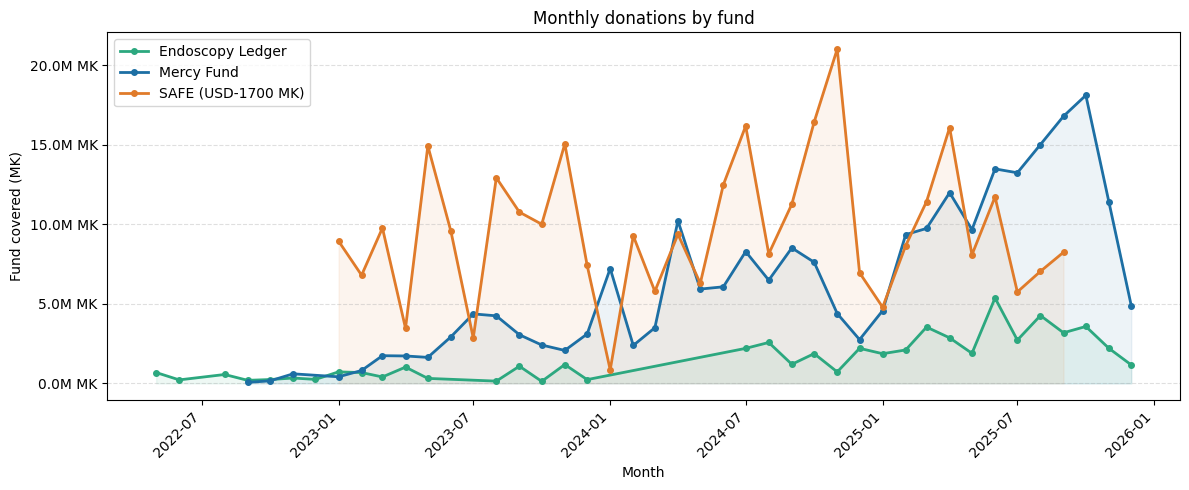

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Prep ──────────────────────────────────────────────────────────────
plot_df = (matched
    .drop_duplicates(subset=["fund","fund_name","fund_admission_date"])
    .copy())
plot_df["month"] = pd.to_datetime(plot_df["fund_admission_date"]).dt.to_period("M")

# For SAFE use safe_ask_usd converted to MK (adjust rate if needed)
USD_TO_MK = 1700
plot_df["covered_mk"] = plot_df.apply(
    lambda r: r["safe_ask_usd"] * USD_TO_MK if r["fund"] == "safe"
              else r["fund_covered_mk"],
    axis=1)

monthly = (plot_df
    .groupby(["month","fund"])["covered_mk"]
    .sum()
    .reset_index())
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

colors = {"mercy": "#1d6fa4", "endo": "#2ca87f", "safe": "#e07b2a"}
labels = {"mercy": "Mercy Fund", "endo": "Endoscopy Ledger", "safe": f"SAFE (USD-{USD_TO_MK} MK)"}

for fund, grp in monthly.groupby("fund"):
    grp = grp.sort_values("month_dt")
    ax.plot(grp["month_dt"], grp["covered_mk"],
            marker="o", markersize=4, linewidth=2,
            color=colors[fund], label=labels[fund])
    ax.fill_between(grp["month_dt"], grp["covered_mk"],
                    alpha=0.08, color=colors[fund])

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1_000_000:.1f}M MK"))
ax.set_xlabel("Month")
ax.set_ylabel("Fund covered (MK)")
ax.set_title("Monthly donations by fund")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig("monthly_covered_by_fund.png", dpi=150)
plt.show()

In [22]:
matched.fund.unique()

array(['mercy', 'safe', 'endo'], dtype=object)